In [3]:
import matplotlib.pyplot as plt
import numpy as np
from galpy.util import conversion
import astropy.units as u
from galpy.potential import (
    MWPotential2014, 
    vcirc,
    evaluateDensities,
    mass,
    HernquistPotential)
from galpy.orbit import Orbit

ro, vo = 8.0 * u.kpc, 220.0 * u.km / u.s
R0 = 8.0 * u.kpc

##Exercise 1

###1. and 3.

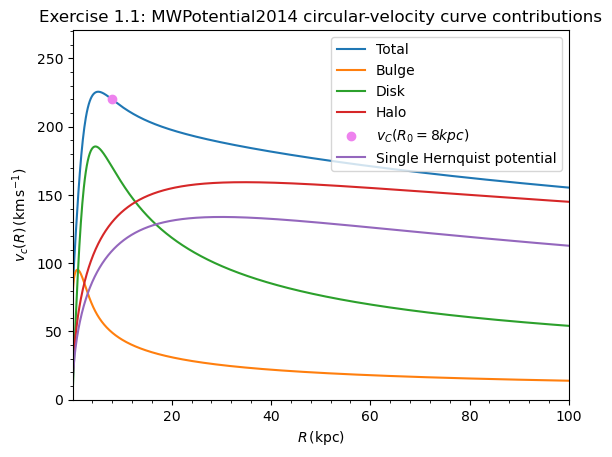

In [7]:
# get each component
bulge = MWPotential2014[0]
disk = MWPotential2014[1]
halo = MWPotential2014[2]

# get each component's vcirc plot in physical units
MWPotential2014.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    label="Total")

bulge.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    overplot=True,
    label="Bulge")

disk.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Disk")
  
halo.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Halo")
        

# find circular velocity at R0 = 8kpc
V0 = vcirc(MWPotential2014, R0.value/ro.value, ro=ro.value, vo=vo.value)
plt.scatter(R0.value, V0, label="$v_C(R_0=8kpc)$",color="violet",zorder=5)

# 3. Add single Hernquist

G = 4.30091e-6 
M  = 1e12
hp = HernquistPotential(
    amp=G * M / (vo.value**2 * ro.value),
    a=30/ro.value)

hp.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Single Hernquist potential"
    )

plt.legend()
plt.title("Exercise 1.1: MWPotential2014 circular-velocity curve contributions")

plt.show()

###2.

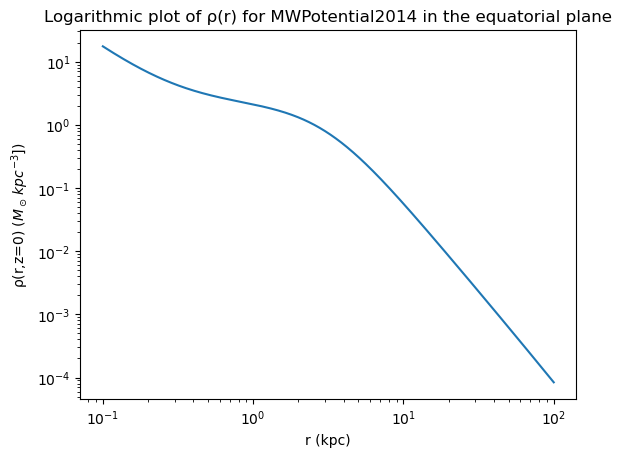

In [5]:
# Density plot
# make an r array from 10e-1 to 10e2 (0.1 to 100kpc)
r = np.logspace(-1,2,500)

# get r in galpy units
r_galpy = r/ro.value

rho = np.array([evaluateDensities(
    MWPotential2014,
    R,
    0.0,
    ro=ro.value,
    vo=vo.value,
    use_physical=True) 
    for R in r_galpy]) 
    
plt.loglog(r, rho)

plt.title("Logarithmic plot of ρ(r) for MWPotential2014 in the equatorial plane")
plt.xlabel("r (kpc)")
plt.ylabel("ρ(r,z=0) ($M_\odot\,{kpc}^{-3}]$)")

plt.show()

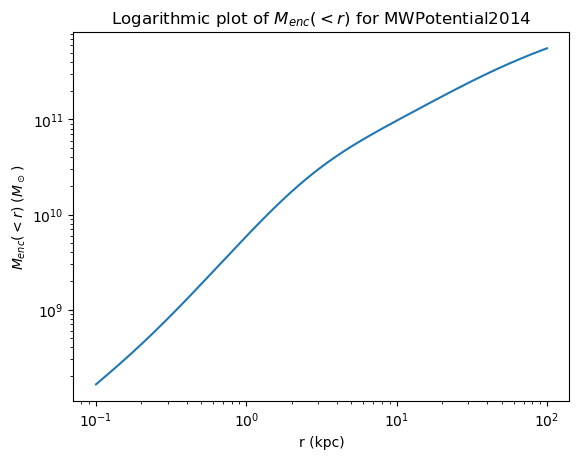

In [6]:
# Mass plot
menc = np.array([mass(
    MWPotential2014,
    R,
    ro=ro.value,
    vo=vo.value,
    use_physical=True,)
    for R in r_galpy])
    
plt.loglog(r, menc)

plt.title("Logarithmic plot of $M_{enc}(<r)$ for MWPotential2014")
plt.xlabel("r (kpc)")
plt.ylabel("$M_{enc}(<r)$ $(M_\odot\,{}$)")

plt.show()